In [1]:
!python -m pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 38.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt 

/var/folders/3_/3_srlh5x2ks_d3fwm32sy80c0000gn/T/ipykernel_27583/2906258467.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  airline['time'] = pd.date_range(start='1949-01', periods=len(airline), freq='M')


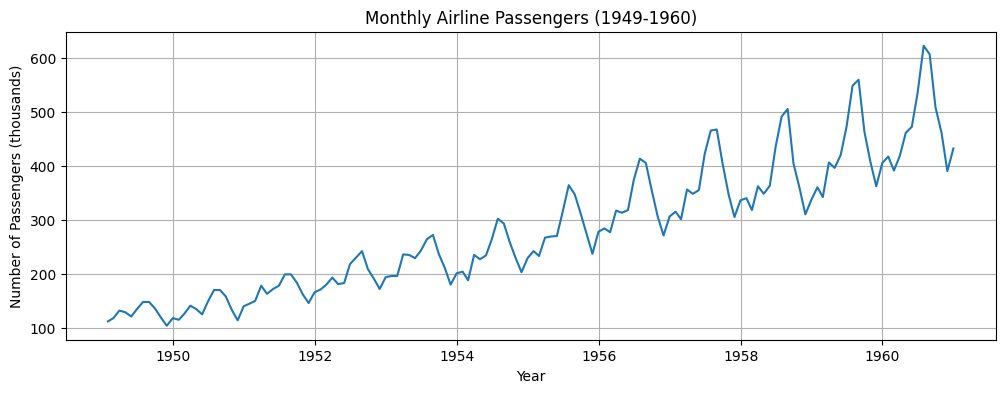

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset

# Load airline passengers data
airline = get_rdataset('AirPassengers').data
airline['time'] = pd.date_range(start='1949-01', periods=len(airline), freq='M')
airline.set_index('time', inplace=True)

# Plot the series
plt.figure(figsize=(12, 4))
plt.plot(airline.index, airline['value'])
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers (thousands)')
plt.grid(True)
plt.show()

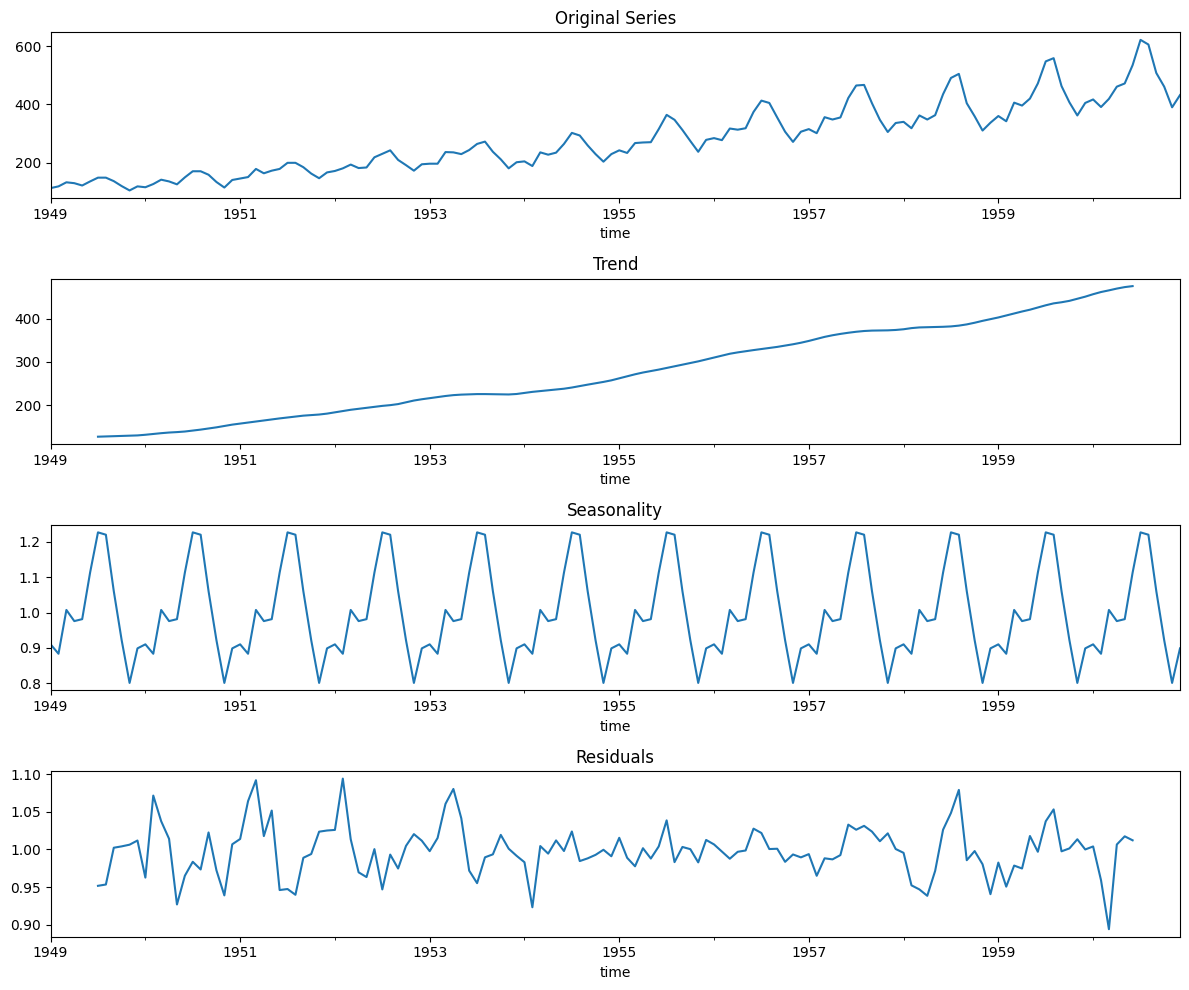

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Multiplicative decomposition (variance increases with level)
decomposition = seasonal_decompose(airline['value'], 
                                   model='multiplicative', 
                                   period=12)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
airline['value'].plot(ax=axes[0], title='Original Series')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.show()